# ORACLE on a PyPSA toy example (4+ variables, KKT/MILP Step 2)

This notebook extends the 2D toy example to **N exploratory variables** using the ORACLE Step-2 KKT/big-M MILP. The MILP is solved with `gurobipy`; the full PyPSA projection solves can use HiGHS or Gurobi.

Distances are computed in normalized coordinates, so `tol_normalized=0.02` means roughly 2% of each variable's VMM range.

In [1]:
import os
os.environ["PROJ_DATA"] = "/home/julian-geis/repos/pypsa-de/.pixi/envs/default/share/proj"

In [2]:
from __future__ import annotations

import itertools
import time
import warnings
from dataclasses import dataclass
from typing import Iterable, List, Tuple

import numpy as np
import pandas as pd
from scipy.optimize import linprog

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import pypsa
except ImportError as exc:
    raise SystemExit("Install pypsa first: mamba install -c conda-forge pypsa highspy scipy matplotlib tqdm") from exc


def log(msg: str, verbose: bool = True):
    if verbose:
        print(msg, flush=True)


In [3]:
TIME_SERIES_URL = "https://model.energy/data/time-series-f17c3736a2719ce7da58484180d89e2d.csv"


def _pick_column(df: pd.DataFrame, candidates: list[str], label: str) -> pd.Series | None:
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return df[lower_map[cand.lower()]].astype(float).clip(0, 1)
    print(f"Warning: no column found for {label}. Tried: {candidates}")
    return None


def synthetic_solar(index: pd.DatetimeIndex) -> pd.Series:
    hour = index.hour.to_numpy()
    values = np.maximum(0.0, np.sin((hour - 6) / 12 * np.pi))
    return pd.Series(values, index=index, name="solar")


def load_capacity_factors(
    start_date: str = "2011-03-01 00:00:00",
    end_date: str = "2011-03-07 23:00:00",
    url: str = TIME_SERIES_URL,
) -> pd.DataFrame:
    raw = pd.read_csv(url, index_col=0, parse_dates=True)
    raw = raw.loc[start_date:end_date]
    if raw.empty:
        raise ValueError("Selected time range is empty.")

    solar = _pick_column(raw, ["solar", "pv", "solar_pv", "solar-utility", "solar_rooftop"], "solar")
    onwind = _pick_column(raw, ["onwind", "onshore_wind", "wind_onshore", "wind"], "onwind")
    offwind = _pick_column(raw, ["offwind", "offwind-ac", "offwind-dc", "offshore_wind", "wind_offshore"], "offwind")

    if solar is None:
        solar = synthetic_solar(raw.index)
    if onwind is None:
        raise ValueError("Could not find an onwind column in the CSV.")
    if offwind is None:
        print("Using clipped 1.15 * onwind as fallback offshore wind profile.")
        offwind = (1.15 * onwind.rolling(3, min_periods=1, center=True).mean()).clip(0, 1)

    out = pd.DataFrame({"solar": solar, "onwind": onwind, "offwind": offwind}, index=raw.index)
    out = out.astype(float).clip(0, 1)
    return out


In [4]:
Z_COMPONENTS = {
    "solar": ("Generator", "solar", "p_nom_opt"),
    "onwind": ("Generator", "onwind", "p_nom_opt"),
    "wind": ("Generator", "onwind", "p_nom_opt"),  # backwards-compatible alias
    "offwind": ("Generator", "offwind", "p_nom_opt"),
    "gas": ("Generator", "gas", "p_nom_opt"),
    "battery_energy": ("Store", "battery_store", "e_nom_opt"),
    "electrolysis": ("Link", "electrolyzer", "p_nom_opt"),
    "h2_store": ("Store", "h2_store", "e_nom_opt"),
    "h2_turbine": ("Link", "h2_turbine", "p_nom_opt"),
}


@dataclass
class OracleResult:
    z_points: np.ndarray
    outer_A: np.ndarray
    outer_b: np.ndarray
    history: pd.DataFrame
    v_star: float
    epsilon: float
    z_names: List[str]
    p_max_pu: pd.DataFrame
    solution_summary: pd.DataFrame


def build_toy_network(
    demand_gw: float = 100.0,
    p_max_pu: pd.DataFrame | None = None,
    start_date: str = "2011-03-01 00:00:00",
    end_date: str = "2011-03-07 23:00:00",
    time_series_url: str = TIME_SERIES_URL,
) -> pypsa.Network:
    if p_max_pu is None:
        p_max_pu = load_capacity_factors(start_date=start_date, end_date=end_date, url=time_series_url)
    else:
        p_max_pu = p_max_pu.copy()

    n = pypsa.Network()
    snapshots = pd.DatetimeIndex(p_max_pu.index)
    n.set_snapshots(snapshots)

    for carrier in ["electricity", "solar", "onwind", "offwind", "gas", "battery", "hydrogen"]:
        n.add("Carrier", carrier)

    n.add("Bus", "electricity", carrier="electricity")
    n.add("Bus", "battery", carrier="battery")
    n.add("Bus", "hydrogen", carrier="hydrogen")
    n.add("Load", "load", bus="electricity", p_set=demand_gw)

    n.add("Generator", "solar", bus="electricity", carrier="solar", p_nom_extendable=True,
          p_max_pu=p_max_pu["solar"], capital_cost=35.0, marginal_cost=0.0)
    n.add("Generator", "onwind", bus="electricity", carrier="onwind", p_nom_extendable=True,
          p_max_pu=p_max_pu["onwind"], capital_cost=50.0, marginal_cost=0.0)
    n.add("Generator", "offwind", bus="electricity", carrier="offwind", p_nom_extendable=True,
          p_max_pu=p_max_pu["offwind"], capital_cost=65.0, marginal_cost=0.0)
    n.add("Generator", "gas", bus="electricity", carrier="gas", p_nom_extendable=True,
          capital_cost=20.0, marginal_cost=90.0)

    n.add("Store", "battery_store", bus="battery", e_nom_extendable=True, e_cyclic=True, capital_cost=15.0)
    n.add("Link", "battery_charge", bus0="electricity", bus1="battery", p_nom_extendable=True, efficiency=0.95, capital_cost=8.0)
    n.add("Link", "battery_discharge", bus0="battery", bus1="electricity", p_nom_extendable=True, efficiency=0.95, capital_cost=8.0)

    n.add("Link", "electrolyzer", bus0="electricity", bus1="hydrogen", p_nom_extendable=True, efficiency=0.70, capital_cost=45.0)
    n.add("Store", "h2_store", bus="hydrogen", e_nom_extendable=True, e_cyclic=True, capital_cost=2.0)
    n.add("Link", "h2_turbine", bus0="hydrogen", bus1="electricity", p_nom_extendable=True, efficiency=0.50, capital_cost=35.0)
    return n


def get_objective_expr(model):
    return getattr(model.objective, "expression", model.objective)


def scalar_var(expr, name: str):
    return expr.sel({expr.dims[0]: name})


def z_expressions(n: pypsa.Network, z_names: Iterable[str]):
    m = n.model
    out = {}
    for z in z_names:
        component, asset, _ = Z_COMPONENTS[z]
        if component == "Generator":
            out[z] = scalar_var(m.variables["Generator-p_nom"], asset)
        elif component == "Link":
            out[z] = scalar_var(m.variables["Link-p_nom"], asset)
        elif component == "Store":
            out[z] = scalar_var(m.variables["Store-e_nom"], asset)
        else:
            raise ValueError(component)
    return out


def evaluate_z(n: pypsa.Network, z_names: Iterable[str]) -> np.ndarray:
    vals = []
    for z in z_names:
        component, asset, attr = Z_COMPONENTS[z]
        table = getattr(n, component.lower() + "s")
        vals.append(float(table.at[asset, attr]))
    return np.array(vals, dtype=float)

def evaluate_all_capacities(n: pypsa.Network) -> dict:
    """Collect installed capacities/energy capacities and objective from a solved network."""
    out = {"objective": float(n.objective)}
    for name, (component, asset, attr) in Z_COMPONENTS.items():
        if name == "wind":
            continue
        table = getattr(n, component.lower() + "s")
        out[name] = float(table.at[asset, attr])

    for link in ["battery_charge", "battery_discharge"]:
        out[link] = float(n.links.at[link, "p_nom_opt"])
    return out


def solution_record(n: pypsa.Network, z_names: Iterable[str], method: str, **meta) -> dict:
    """Store all capacities and cost for a solved ORACLE/VMM point."""
    rec = evaluate_all_capacities(n)
    z = evaluate_z(n, z_names)
    for name, value in zip(z_names, z):
        rec[name] = float(value)
    rec.update({"method": method, **meta})
    return rec


def solve_baseline(template: pypsa.Network, solver_name="highs", solver_options=None, verbose=True) -> Tuple[pypsa.Network, float]:
    t0 = time.perf_counter()
    n = template.copy()
    log("Solving baseline model...", verbose)
    n.optimize(solver_name=solver_name, solver_options=solver_options or {})
    log(f"Baseline solved in {time.perf_counter() - t0:.1f} s; objective={float(n.objective):,.2f}", verbose)
    return n, float(n.objective)


def solve_with_custom_objective(template, z_names, v_star, epsilon, objective_builder,
                                solver_name="highs", solver_options=None, verbose=False):
    n = template.copy()
    n.optimize.create_model()
    m = n.model
    original_objective = get_objective_expr(m)
    m.add_constraints(original_objective <= v_star * (1.0 + epsilon), name="oracle_budget")
    z_expr = z_expressions(n, z_names)
    objective = objective_builder(n, m, z_expr)
    m.add_objective(objective, overwrite=True)
    n.optimize.solve_model(solver_name=solver_name, solver_options=solver_options or {})
    return n


def vmm_initialization(template, z_names, v_star, epsilon, solver_name="highs", solver_options=None, verbose=True):
    points = []
    rows = []
    solution_rows = []
    log("Running VMM initialization...", verbose)
    t_all = time.perf_counter()
    tasks = [(name, "min") for name in z_names] + [(name, "max") for name in z_names]
    for name, sense in tqdm(tasks, desc="VMM", disable=not verbose):
        t0 = time.perf_counter()
        if sense == "min":
            obj = lambda n, m, z_expr, name=name: z_expr[name]
        else:
            obj = lambda n, m, z_expr, name=name: -z_expr[name]
        n_sol = solve_with_custom_objective(template, z_names, v_star, epsilon, obj, solver_name, solver_options)
        seconds = time.perf_counter() - t0
        z = evaluate_z(n_sol, z_names)
        points.append(z)
        rows.append({"variable": name, "sense": sense, "seconds": seconds, **dict(zip(z_names, z))})
        solution_rows.append(solution_record(n_sol, z_names, method="VMM", variable=name, sense=sense, seconds=seconds))
        log(f"  VMM {sense:3s} {name:10s}: {seconds:.1f} s, z={z}", verbose)
    Z = np.vstack(points)
    log(f"VMM finished in {time.perf_counter() - t_all:.1f} s", verbose)
    return Z, Z.min(axis=0), Z.max(axis=0), pd.DataFrame(rows), pd.DataFrame(solution_rows)



In [5]:

@dataclass
class OracleNDResult:
    z_points: np.ndarray          # physical units
    y_points: np.ndarray          # normalized coordinates
    outer_A: np.ndarray           # cuts in normalized coordinates
    outer_b: np.ndarray
    history: pd.DataFrame
    v_star: float
    epsilon: float
    z_names: List[str]
    p_max_pu: pd.DataFrame
    solution_summary: pd.DataFrame
    z_min: np.ndarray
    z_scale: np.ndarray


def scale_z(z: np.ndarray, z_min: np.ndarray, z_scale: np.ndarray) -> np.ndarray:
    return (np.asarray(z, dtype=float) - z_min) / z_scale


def unscale_y(y: np.ndarray, z_min: np.ndarray, z_scale: np.ndarray) -> np.ndarray:
    return z_min + z_scale * np.asarray(y, dtype=float)


def halfspace_unit_box(nz: int):
    """Initial outer approximation in normalized y-space: 0 <= y_j <= 1."""
    A = np.vstack([np.eye(nz), -np.eye(nz)])
    b = np.r_[np.ones(nz), np.zeros(nz)]
    return A.astype(float), b.astype(float)


def farthest_trial_point_kkt_milp(
    Y_points: np.ndarray,
    outer_A: np.ndarray,
    outer_b: np.ndarray,
    time_limit: float = 120,
    mip_gap: float = 1e-4,
    threads: int | None = None,
    output_flag: bool = False,
    M_primal: float = 2.0,
    M_dual_norm: float = 1.0,
    M_dual_lambda: float = 100.0,
    active_set_tightening: bool = True,
):
    """KKT/big-M MILP for ORACLE Step 2 in normalized coordinates.

    Solves max_{y_O in O} min_{y_I in conv(Y_points)} ||y_O - y_I||_inf.
    This is the 4+ dimensional replacement for the 2D vertex-enumeration step.

    Requires gurobipy.
    """
    try:
        import gurobipy as gp
        from gurobipy import GRB
    except Exception as exc:
        raise ImportError(
            "The KKT/MILP Step-2 implementation requires gurobipy. "
            "Install gurobi/gurobipy and make sure your license is active."
        ) from exc

    Y_points = np.asarray(Y_points, dtype=float)
    outer_A = np.asarray(outer_A, dtype=float)
    outer_b = np.asarray(outer_b, dtype=float)
    m_pts, nz = Y_points.shape

    model = gp.Model("oracle_step2_kkt_milp")
    model.Params.OutputFlag = int(output_flag)
    model.Params.TimeLimit = time_limit
    model.Params.MIPGap = mip_gap
    if threads is not None:
        model.Params.Threads = threads

    # Upper-level trial point in normalized coordinates. Box bounds are valid after VMM scaling.
    yO = model.addVars(nz, lb=0.0, ub=1.0, name="yO")

    # Lower-level primal variables: closest point in inner convex hull and infinity distance.
    lam = model.addVars(m_pts, lb=0.0, ub=1.0, name="lambda")
    t = model.addVar(lb=0.0, ub=1.0, name="t")

    # Lower-level dual variables.
    alpha = model.addVars(nz, lb=0.0, ub=M_dual_norm, name="alpha_plus")
    beta = model.addVars(nz, lb=0.0, ub=M_dual_norm, name="beta_minus")
    gamma = model.addVars(m_pts, lb=0.0, ub=M_dual_lambda, name="gamma_lambda_lb")
    eta = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, name="eta_sum_lambda")

    # Binary variables for complementarity.
    u_plus = model.addVars(nz, vtype=GRB.BINARY, name="u_plus_active")
    u_minus = model.addVars(nz, vtype=GRB.BINARY, name="u_minus_active")
    u_lam = model.addVars(m_pts, vtype=GRB.BINARY, name="u_lambda_lb_active")

    # Outer approximation: A yO <= b.
    for r in range(len(outer_b)):
        model.addConstr(gp.quicksum(outer_A[r, j] * yO[j] for j in range(nz)) <= outer_b[r], name=f"outer_{r}")

    # Convex combination.
    model.addConstr(gp.quicksum(lam[i] for i in range(m_pts)) == 1.0, name="lambda_sum")

    # Lower-level primal constraints and complementarity for infinity norm.
    for j in range(nz):
        yI_j = gp.quicksum(Y_points[i, j] * lam[i] for i in range(m_pts))

        slack_plus = yO[j] - yI_j - t
        model.addConstr(slack_plus <= 0.0, name=f"primal_plus_{j}")
        model.addConstr(slack_plus >= -M_primal * (1 - u_plus[j]), name=f"comp_plus_slack_{j}")
        model.addConstr(alpha[j] <= M_dual_norm * u_plus[j], name=f"comp_plus_dual_{j}")

        slack_minus = -yO[j] + yI_j - t
        model.addConstr(slack_minus <= 0.0, name=f"primal_minus_{j}")
        model.addConstr(slack_minus >= -M_primal * (1 - u_minus[j]), name=f"comp_minus_slack_{j}")
        model.addConstr(beta[j] <= M_dual_norm * u_minus[j], name=f"comp_minus_dual_{j}")

    # Complementarity for lambda_i >= 0, written as -lambda_i <= 0.
    for i in range(m_pts):
        model.addConstr(lam[i] <= 1.0 * (1 - u_lam[i]), name=f"comp_lambda_slack_{i}")
        model.addConstr(gamma[i] <= M_dual_lambda * u_lam[i], name=f"comp_lambda_dual_{i}")

    # Stationarity of the lower-level LP.
    model.addConstr(1.0 - gp.quicksum(alpha[j] + beta[j] for j in range(nz)) == 0.0, name="stationarity_t")
    for i in range(m_pts):
        model.addConstr(
            gp.quicksum((-Y_points[i, j]) * alpha[j] + Y_points[i, j] * beta[j] for j in range(nz))
            - gamma[i] + eta == 0.0,
            name=f"stationarity_lambda_{i}",
        )

    # Optional tightening from Caratheodory / infinity-norm structure.
    if active_set_tightening:
        n_positive_lambda = gp.quicksum(1 - u_lam[i] for i in range(m_pts))
        n_active_norm = gp.quicksum(u_plus[j] + u_minus[j] for j in range(nz))
        model.addConstr(n_positive_lambda >= 1, name="tight_lambda_min")
        model.addConstr(n_positive_lambda <= nz + 1, name="tight_lambda_max")
        model.addConstr(n_active_norm >= 1, name="tight_norm_min")
        model.addConstr(n_active_norm <= nz, name="tight_norm_max")

    model.setObjective(t, GRB.MAXIMIZE)
    model.optimize()

    if model.SolCount == 0:
        raise RuntimeError(f"Step-2 KKT/MILP found no feasible solution. Gurobi status={model.Status}")

    y_trial = np.array([yO[j].X for j in range(nz)], dtype=float)
    d_oi = float(t.X)
    info = {
        "status": int(model.Status),
        "objective_bound": float(model.ObjBound) if model.SolCount else np.nan,
        "mip_gap": float(model.MIPGap) if model.SolCount and model.IsMIP else np.nan,
        "runtime": float(model.Runtime),
        "node_count": float(model.NodeCount),
    }
    return y_trial, d_oi, info


def solve_projection_scaled(
    template,
    z_names,
    y_trial,
    z_min,
    z_scale,
    v_star,
    epsilon,
    solver_name="highs",
    solver_options=None,
    verbose=True,
):
    """ORACLE Step 3: full PyPSA projection solve using normalized infinity distance."""
    t0 = time.perf_counter()
    y_trial = np.asarray(y_trial, dtype=float)
    n = template.copy()
    n.optimize.create_model()
    m = n.model
    original_objective = get_objective_expr(m)
    m.add_constraints(original_objective <= v_star * (1.0 + epsilon), name="oracle_budget")
    z_expr = z_expressions(n, z_names)

    rho = m.add_variables(lower=0, name="oracle_rho")
    for j, name in enumerate(z_names):
        y_expr = (z_expr[name] - float(z_min[j])) / float(z_scale[j])
        delta = m.add_variables(lower=-np.inf, name=f"oracle_delta_{name}")
        m.add_constraints(y_trial[j] - y_expr == delta, name=f"oracle_delta_def_{name}")
        m.add_constraints(delta <= rho, name=f"oracle_delta_pos_{name}")
        m.add_constraints(-delta <= rho, name=f"oracle_delta_neg_{name}")

    m.add_objective(rho, overwrite=True)
    n.optimize.solve_model(solver_name=solver_name, solver_options=solver_options or {})

    z_feas = evaluate_z(n, z_names)
    y_feas = scale_z(z_feas, z_min, z_scale)
    distance = float(np.max(np.abs(y_trial - y_feas)))

    mu = []
    for name in z_names:
        try:
            dual = m.constraints[f"oracle_delta_def_{name}"].dual
            mu.append(float(dual.values))
        except Exception:
            mu = None
            break
    if mu is not None:
        mu = np.array(mu, dtype=float)
        if mu @ y_trial < mu @ y_feas:
            mu = -mu
        if mu @ y_trial <= mu @ y_feas + 1e-7:
            mu = None

    if mu is None:
        warnings.warn("Could not extract a strict dual cut; using heuristic cut normal. This is not rigorous.")
        mu = y_trial - y_feas
        if np.linalg.norm(mu) < 1e-9:
            mu = None

    log(f"  projection solved in {time.perf_counter() - t0:.1f} s; d_proj={distance:.4g}; z_feas={z_feas}", verbose)
    return n, z_feas, y_feas, distance, mu


def run_oracle_nd_kkt(
    epsilon=0.10,
    tol_normalized=0.02,
    max_iter=10,
    z_names=("solar", "onwind", "offwind", "battery_energy"),
    solver_name="highs",
    solver_options=None,
    metric_time_limit=120,
    metric_mip_gap=1e-4,
    metric_threads=None,
    demand_gw=100.0,
    p_max_pu: pd.DataFrame | None = None,
    start_date: str = "2011-03-01 00:00:00",
    end_date: str = "2011-03-07 23:00:00",
    time_series_url: str = TIME_SERIES_URL,
    verbose=True,
) -> OracleNDResult:
    """ORACLE for 2+ exploratory variables using the KKT/big-M MILP Step 2.

    The distance tolerance is in normalized units because variables may have different units.
    Example: tol_normalized=0.02 means about 2% of each variable's VMM range.
    """
    z_names = list(z_names)
    if len(z_names) < 2:
        raise ValueError("Use VMM min/max for one exploratory variable; ORACLE needs at least two.")

    t_total = time.perf_counter()
    if p_max_pu is None:
        p_max_pu = load_capacity_factors(start_date=start_date, end_date=end_date, url=time_series_url)
    template = build_toy_network(demand_gw=demand_gw, p_max_pu=p_max_pu)

    n_opt, v_star = solve_baseline(template, solver_name, solver_options, verbose)
    z_star = evaluate_z(n_opt, z_names)
    baseline_row = solution_record(n_opt, z_names, method="cost_optimum", variable="objective", sense="min", seconds=np.nan)
    log(f"Cost-optimal z={z_star}", verbose)

    Z_vmm, z_min_vmm, z_max_vmm, vmm_log, vmm_solutions = vmm_initialization(
        template, z_names, v_star, epsilon, solver_name, solver_options, verbose
    )

    Z_points = np.vstack([z_star, Z_vmm])
    z_min = np.minimum(Z_points.min(axis=0), z_min_vmm)
    z_max = np.maximum(Z_points.max(axis=0), z_max_vmm)
    z_scale = z_max - z_min
    z_scale[z_scale < 1e-9] = 1.0
    Y_points = scale_z(Z_points, z_min, z_scale)

    solution_rows = [baseline_row] + vmm_solutions.to_dict("records")
    A, b = halfspace_unit_box(len(z_names))

    rows = []
    iterator = tqdm(range(max_iter), desc="ORACLE-KKT", disable=not verbose)
    for k in iterator:
        t_iter = time.perf_counter()
        y_trial, d_oi, metric_info = farthest_trial_point_kkt_milp(
            Y_points, A, b,
            time_limit=metric_time_limit,
            mip_gap=metric_mip_gap,
            threads=metric_threads,
            output_flag=False,
        )
        z_trial = unscale_y(y_trial, z_min, z_scale)
        log(f"iter={k:02d} d_OI={d_oi:.4g} y_trial={np.round(y_trial, 4)} points={len(Y_points)} cuts={len(b)}", verbose)

        row = {
            "iteration": k,
            "d_oi_normalized": d_oi,
            "metric_runtime": metric_info.get("runtime", np.nan),
            "metric_mip_gap": metric_info.get("mip_gap", np.nan),
            "n_points_before": len(Y_points),
            "n_cuts_before": len(b),
        }
        for name, val in zip(z_names, z_trial):
            row[f"trial_{name}"] = float(val)

        if d_oi <= tol_normalized:
            row.update({"d_proj_normalized": np.nan, "seconds": time.perf_counter() - t_iter, "stopped": True})
            rows.append(row)
            break

        n_proj, z_feas, y_feas, d_proj, mu = solve_projection_scaled(
            template, z_names, y_trial, z_min, z_scale, v_star, epsilon, solver_name, solver_options, verbose
        )
        Z_points = np.vstack([Z_points, z_feas])
        Y_points = np.vstack([Y_points, y_feas])
        solution_rows.append(solution_record(n_proj, z_names, method="ORACLE_projection", iteration=k, d_proj_normalized=d_proj, seconds=np.nan))

        added_cut = False
        if d_proj > 1e-6 and mu is not None:
            new_b = float(mu @ y_feas)
            # Validate against all known feasible points before adding.
            if np.all(Y_points @ mu <= new_b + 1e-5) and (mu @ y_trial > new_b + 1e-7):
                A = np.vstack([A, mu])
                b = np.r_[b, new_b]
                added_cut = True
            else:
                warnings.warn("Skipped cut because validation failed.")

        row.update({
            "d_proj_normalized": d_proj,
            "added_cut": added_cut,
            "seconds": time.perf_counter() - t_iter,
            "stopped": False,
        })
        for name, val in zip(z_names, z_feas):
            row[f"feas_{name}"] = float(val)
        rows.append(row)

    hist = pd.DataFrame(rows)
    hist.attrs["vmm_log"] = vmm_log
    solution_summary = pd.DataFrame(solution_rows)
    solution_summary["cost_gap_percent"] = 100.0 * (solution_summary["objective"] / v_star - 1.0)
    log(f"ORACLE-KKT total runtime: {time.perf_counter() - t_total:.1f} s", verbose)
    return OracleNDResult(Z_points, Y_points, A, b, hist, v_star, epsilon, z_names, p_max_pu, solution_summary, z_min, z_scale)


def plot_oracle_pair_projection(
    res: OracleNDResult,
    x_name: str | None = None,
    y_name: str | None = None,
    color="cost_gap_percent",
    path="/home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_toy_2d.png",
):
    """Plot solved ORACLE/VMM points projected onto two selected exploratory variables."""
    import matplotlib.pyplot as plt
    if x_name is None:
        x_name = res.z_names[0]
    if y_name is None:
        y_name = res.z_names[1]
    df = res.solution_summary.copy()
    fig, ax = plt.subplots(figsize=(7, 5))
    if color in df.columns:
        sc = ax.scatter(df[x_name], df[y_name], c=df[color], s=90)
        fig.colorbar(sc, ax=ax, label=color)
    else:
        ax.scatter(df[x_name], df[y_name], s=90)
    ax.set_xlabel(f"{x_name} capacity")
    ax.set_ylabel(f"{y_name} capacity")
    ax.set_title(f"ORACLE-KKT points projected to {x_name} vs {y_name}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    try:
        fig.savefig(path, dpi=160)
        print(f"Saved {path}")
    except FileNotFoundError:
        fallback = "/mnt/data/oracle_toy_2d.png"
        fig.savefig(fallback, dpi=160)
        print(f"Could not save to requested path; saved fallback {fallback}")
    return fig


def plot_metric_history(res: OracleNDResult):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(res.history["iteration"], res.history["d_oi_normalized"], marker="o", label="d_OI")
    if "d_proj_normalized" in res.history:
        ax.plot(res.history["iteration"], res.history["d_proj_normalized"], marker="x", label="projection distance")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Normalized infinity distance")
    ax.set_title("ORACLE-KKT convergence")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


## 1. Configure snapshots and load real capacity factors

In [6]:
start_date = "2011-03-01 00:00:00"
end_date = "2011-03-03 23:00:00"

demand_gw = 100.0
solver_name = "highs"          # PyPSA LP solver; use "gurobi" if preferred
solver_options = {"time_limit": 120}

p_max_pu_select = load_capacity_factors(start_date=start_date, end_date=end_date)
print(p_max_pu_select.head())
print("Snapshots:", len(p_max_pu_select), p_max_pu_select.index[0], "to", p_max_pu_select.index[-1])

Using clipped 1.15 * onwind as fallback offshore wind profile.
                     solar  onwind   offwind
time                                        
2011-03-01 00:00:00    0.0   0.112  0.146625
2011-03-01 01:00:00    0.0   0.143  0.165217
2011-03-01 02:00:00    0.0   0.176  0.205083
2011-03-01 03:00:00    0.0   0.216  0.248400
2011-03-01 04:00:00    0.0   0.256  0.284433
Snapshots: 72 2011-03-01 00:00:00 to 2011-03-03 23:00:00


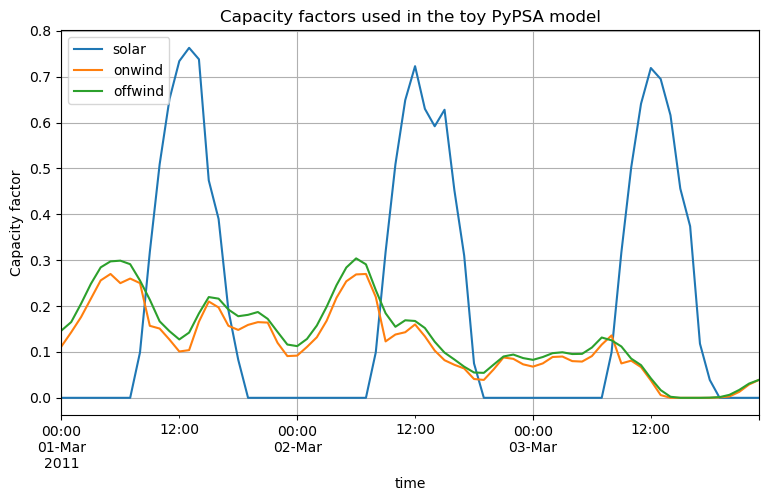

In [7]:
import matplotlib.pyplot as plt

p_max_pu_select[["solar", "onwind", "offwind"]].plot(
    title="Capacity factors used in the toy PyPSA model",
    ylabel="Capacity factor",
    grid=True,
    figsize=(9, 5),
)
plt.show()

## 2. Smoke test: solve the default PyPSA model once

In [8]:
template = build_toy_network(demand_gw=demand_gw, p_max_pu=p_max_pu_select)
n_base, v_star = solve_baseline(template, solver_name=solver_name, solver_options=solver_options, verbose=True)
print("z(solar, onwind, offwind, battery_energy) =", evaluate_z(n_base, ["solar", "onwind", "offwind", "battery_energy"]))

Solving baseline model...


/tmp/ipykernel_79495/3419967377.py:130: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.14s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1810 duals
Objective: 4.53e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-r3h7ugi7 has 1810 rows; 874 cols; 3563 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 1e+00]
  Cost    [2e+00, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 1e+02]
Presolving model
1033 rows, 827 cols, 2739 nonzeros  0s
889 rows, 683 cols, 2451 nonzeros  0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
889 rows, 683 cols, 2451 nonzeros  0s
Presolve reductions: rows 889(-921); columns 683(-191); nonzeros 2451(-1112) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 72(4800) 0.0s
        718     4.5253997086e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-r3h7ugi7
Model status        : Optimal
S

## 3. Run ORACLE with 4 exploratory variables

In [9]:
epsilon = 0.10
z_names_nd = ["solar", "onwind", "offwind", "battery_energy"]

# A loose tolerance and few iterations are best for a first test.
result_nd = run_oracle_nd_kkt(
    epsilon=epsilon,
    tol_normalized=0.05,
    max_iter=5,
    z_names=z_names_nd,
    solver_name=solver_name,
    solver_options=solver_options,
    metric_time_limit=120,
    metric_mip_gap=1e-4,
    demand_gw=demand_gw,
    p_max_pu=p_max_pu_select,
    verbose=True,
)

result_nd.history

Solving baseline model...


/tmp/ipykernel_79495/3419967377.py:130: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.04s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1810 duals
Objective: 4.53e+04
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance were not assigned to the network.


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-f2c3de_b has 1810 rows; 874 cols; 3563 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 1e+00]
  Cost    [2e+00, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [1e+02, 1e+02]
Presolving model
1033 rows, 827 cols, 2739 nonzeros  0s
889 rows, 683 cols, 2451 nonzeros  0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
889 rows, 683 cols, 2451 nonzeros  0s
Presolve reductions: rows 889(-921); columns 683(-191); nonzeros 2451(-1112) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 72(4800) 0.0s
        718     4.5253997086e+04 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-f2c3de_b
Model status        : Optimal
S

VMM:   0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipykernel_79495/3419967377.py:138: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 874 primals, 1811 duals
Objective: 3.00e+02
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, oracle_budget were not assigned to the network.


...

/tmp/ipykernel_79495/2742007857.py:169: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.1s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 879 primals, 1823 duals
Objective: 2.95e-01
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The variable 'oracle_rho' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:The variable 'oracle_delta_solar' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:The

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-8b192ful has 1823 rows; 879 cols; 3669 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 9e+01]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [7e-01, 5e+04]
Presolving model
1041 rows, 828 cols, 2835 nonzeros  0s
897 rows, 684 cols, 2547 nonzeros  0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
897 rows, 684 cols, 2547 nonzeros  0s
Presolve reductions: rows 897(-926); columns 684(-195); nonzeros 2547(-1122) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 75(9686.99) 0.0s
        509     2.9470220747e-01 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-8b192ful
Model status        : Optima

/tmp/ipykernel_79495/2742007857.py:169: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - time_limit: 120
INFO:linopy.io: Writing time: 0.07s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 879 primals, 1823 duals
Objective: 2.91e-01
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The variable 'oracle_rho' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:The variable 'oracle_delta_solar' could not be mapped to the network component because it does not include the symbol '-'.
INFO:pypsa.optimization.optimize:Th

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-hrd05eo6 has 1823 rows; 879 cols; 3669 nonzeros
Coefficient ranges:
  Matrix  [4e-04, 9e+01]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [5e-01, 5e+04]
Presolving model
1040 rows, 828 cols, 2833 nonzeros  0s
896 rows, 684 cols, 2545 nonzeros  0s
Dependent equations search running on 216 equations with time limit of 1.20s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1.20s)
896 rows, 684 cols, 2545 nonzeros  0s
Presolve reductions: rows 896(-927); columns 684(-195); nonzeros 2545(-1124) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 74(9510.04) 0.0s
        630     2.9074419101e-01 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-hrd05eo6
Model status        : Optima

,iteration,d_oi_normalized,metric_runtime,metric_mip_gap,n_points_before,n_cuts_before,trial_solar,trial_onwind,trial_offwind,trial_battery_energy,d_proj_normalized,added_cut,seconds,stopped,feas_solar,feas_onwind,feas_offwind,feas_battery_energy
0,0,0.641168,0.043939,0.0,9,8,714.986997,460.999469,276.014598,1873.915721,0.632974,True,0.689031,False,452.562327,169.199006,101.304663,1081.798968
1,1,0.369999,0.028700,0.0,10,9,714.986997,0.000000,0.000000,622.494118,0.319754,True,0.686715,False,582.419925,113.424577,-0.000000,1022.641705
2,2,0.366831,0.034101,0.0,11,10,300.396723,0.000000,253.462529,1873.915721,0.322769,True,0.784689,False,411.556142,-0.000000,164.373642,1469.995933
3,3,0.341219,0.052096,0.0,12,11,300.396723,352.566803,0.000000,1873.915721,0.294702,True,0.732461,False,393.523964,216.709242,-0.000000,1505.119012
4,4,0.310883,0.053613,0.0,13,12,300.396723,0.000000,0.000000,622.494118,0.290744,True,0.716924,False,420.936437,134.032918,80.249641,986.337680


In [10]:
result_nd.solution_summary

,objective,solar,onwind,offwind,gas,battery_energy,electrolysis,h2_store,h2_turbine,battery_charge,battery_discharge,method,variable,sense,seconds,iteration,d_proj_normalized,cost_gap_percent
0,45253.997086,545.875165,-0.000000,-0.000000,-0.000000,1509.816837,2.245018,51.859924,3.241245,290.239225,107.626335,cost_optimum,objective,min,NaN,NaN,NaN,0.000000
1,300.396723,300.396723,440.635802,-0.000000,-0.000000,826.908499,24.447347,619.209379,18.999399,133.521046,94.799647,VMM,solar,min,0.525697,NaN,NaN,-99.336198
2,0.000000,409.263117,-0.000000,241.082853,-0.000000,1153.977590,-0.000000,-0.000000,-0.000000,204.518257,104.874042,VMM,onwind,min,0.487735,NaN,NaN,-100.000000
3,0.000000,351.495595,407.417685,-0.000000,-0.000000,994.788982,-0.000000,-0.000000,-0.000000,168.207205,104.834297,VMM,offwind,min,0.493022,NaN,NaN,-100.000000
4,622.494118,368.409899,390.625000,-0.000000,-0.000000,622.494118,63.412866,903.485528,51.526764,116.317601,77.732624,VMM,battery_energy,min,0.478382,NaN,NaN,-98.624444
5,-714.986997,714.986997,-0.000000,-0.000000,-0.000000,1450.239194,3.927434,78.472188,4.904512,206.727738,105.263158,VMM,solar,max,0.737469,NaN,NaN,-101.579942
6,-460.999469,322.050824,460.999469,-0.000000,-0.000000,667.465665,25.075339,649.841204,35.102625,137.321542,86.302829,VMM,onwind,max,0.491206,NaN,NaN,-101.018693
7,-276.014598,384.490631,-0.000000,276.014598,-0.000000,924.703880,17.225855,403.963073,23.192188,171.876435,92.611246,VMM,offwind,max,0.480132,NaN,NaN,-100.609923
8,-1873.915721,529.177817,-0.000000,-0.000000,-0.000000,1873.915721,-0.000000,-0.000000,-0.000000,288.416517,105.263158,VMM,battery_energy,max,0.485413,NaN,NaN,-104.140884
9,0.632974,452.562327,169.199006,101.304663,-0.000000,1081.798968,4.091005,97.506344,6.500423,156.169073,101.500269,ORACLE_projection,NaN,NaN,NaN,0.0,0.632974,-99.998601


## 4. Diagnostics

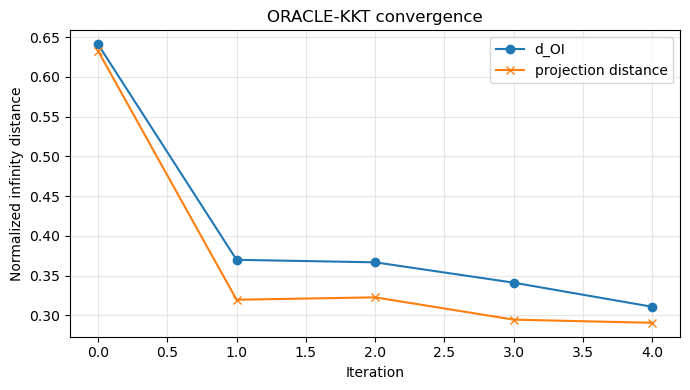

In [11]:
plot_metric_history(result_nd)
plt.show()

Saved /home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_toy_2d.png


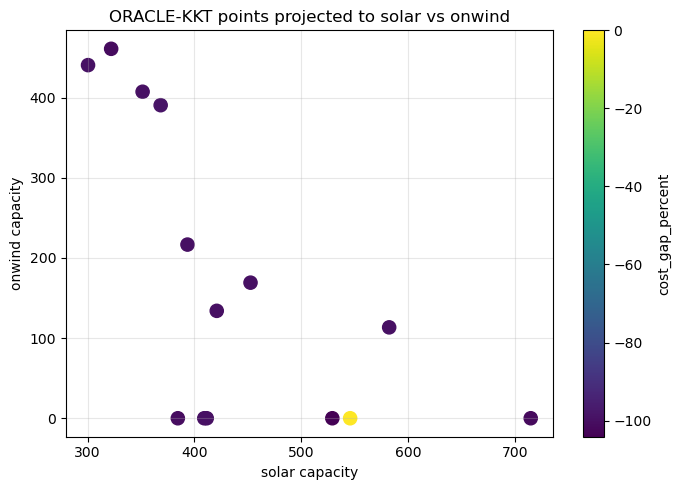

In [12]:
plot_oracle_pair_projection(
    result_nd,
    x_name="solar",
    y_name="onwind",
    color="cost_gap_percent",
    path="/home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_toy_2d.png",
)
plt.show()

Saved /home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_nd_tech_cost_maps.png


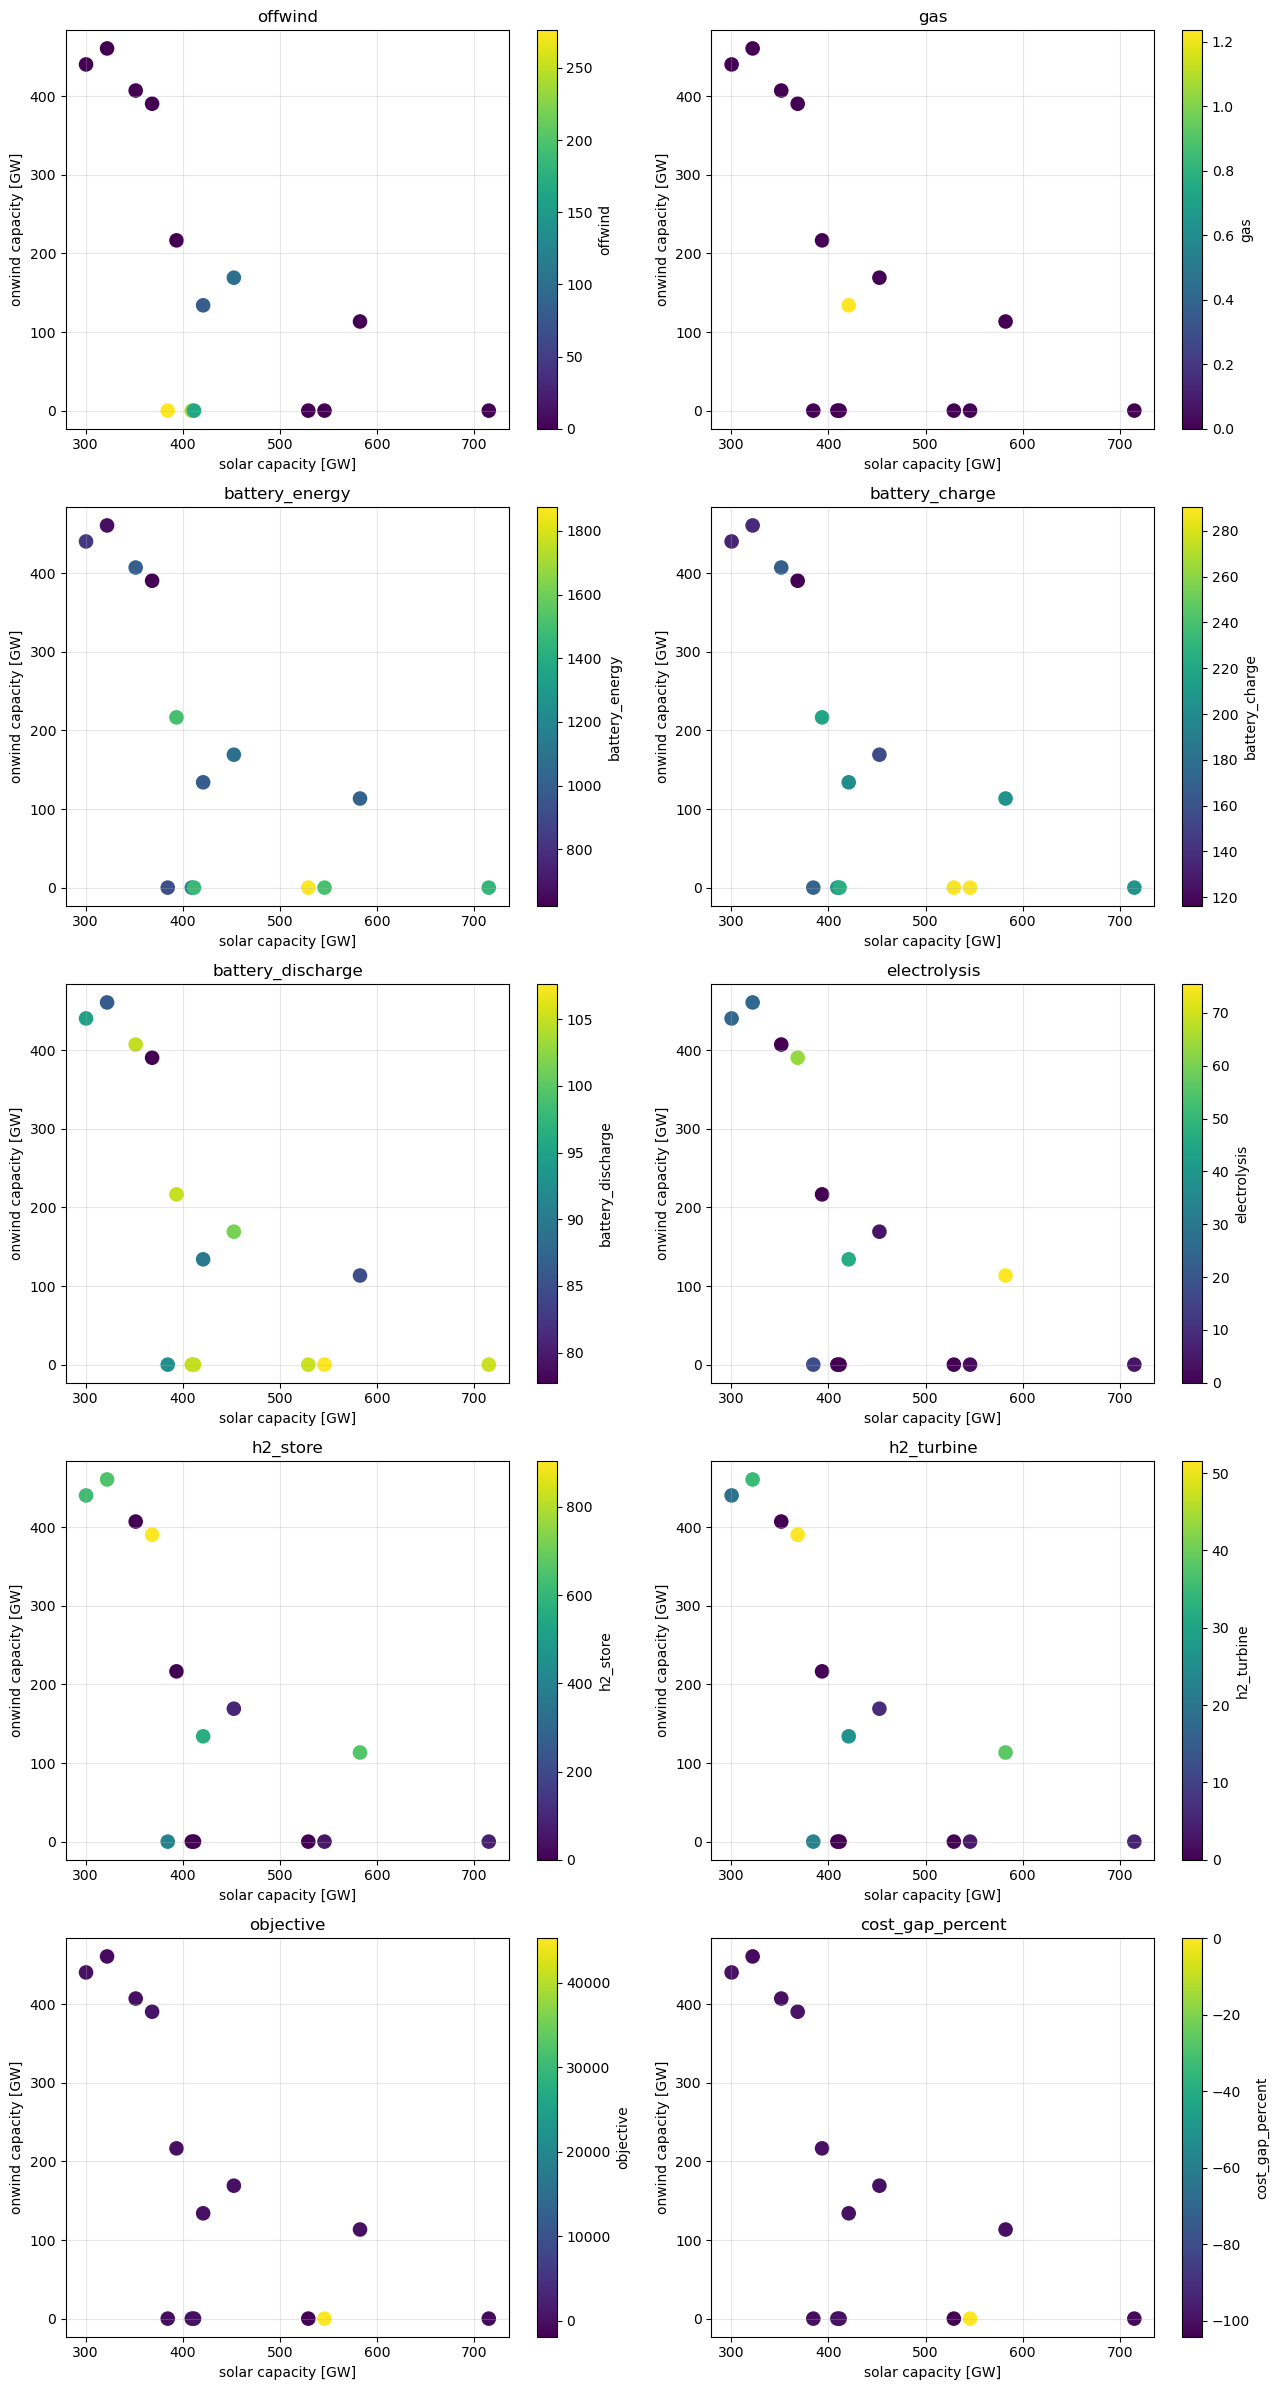

In [13]:
def plot_capacity_and_cost_maps(df: pd.DataFrame, z_names: list[str], path="/mnt/data/oracle_tech_cost_maps.png"):
    """Scatter maps: x/y are explored capacities, color shows other capacities or cost."""
    import math
    import matplotlib.pyplot as plt

    x, y = z_names
    value_cols = [
        c for c in [
            "offwind", "gas", "battery_energy", "battery_charge", "battery_discharge",
            "electrolysis", "h2_store", "h2_turbine", "objective", "cost_gap_percent"
        ]
        if c in df.columns and c not in z_names
    ]

    ncols = 2
    nrows = math.ceil(len(value_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.8 * nrows), squeeze=False)

    for ax, col in zip(axes.ravel(), value_cols):
        sc = ax.scatter(df[x], df[y], c=df[col], s=90)
        ax.set_xlabel(f"{x} capacity [GW]")
        ax.set_ylabel(f"{y} capacity [GW]")
        ax.set_title(col)
        ax.grid(True, alpha=0.3)
        fig.colorbar(sc, ax=ax, label=col)

    for ax in axes.ravel()[len(value_cols):]:
        ax.axis("off")

    fig.tight_layout()
    fig.savefig(path, dpi=160)
    print(f"Saved {path}")
    return fig

# Capacity/cost maps from cached solved points; no re-optimization.
plot_capacity_and_cost_maps(result_nd.solution_summary, ["solar", "onwind"], path="/home/julian-geis/Documents/06_PhD/03RobustModelling/ORACLE/oracle_nd_tech_cost_maps.png")
plt.show()

## Notes

- The strict separating cut uses the duals from the normalized projection solve. If dual extraction fails, the notebook falls back to a heuristic cut and warns you; that fallback is useful for debugging but is not a rigorous ORACLE cut.
- The optional value-function/cost cut from the supplement is not included here yet. This implementation is the core KKT/MILP Step-2 ORACLE loop.

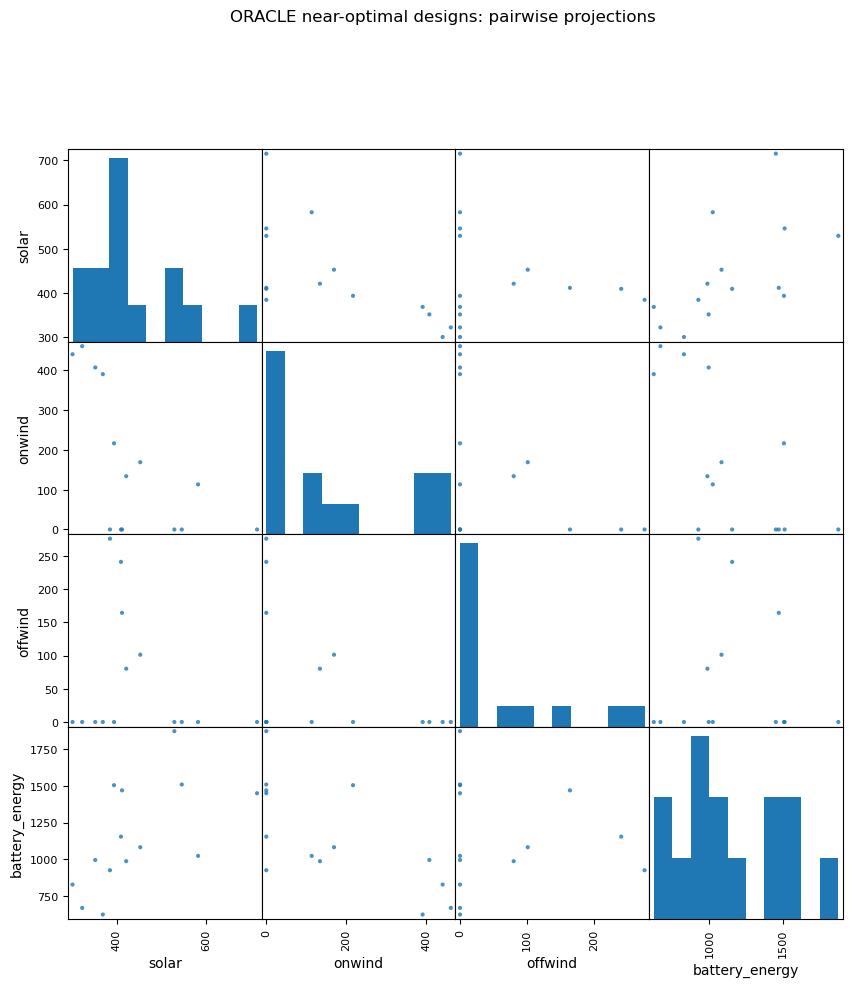

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

df = result_nd.solution_summary.copy()

cols = ["solar", "onwind", "offwind", "battery_energy"]

scatter_matrix(
    df[cols],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.8,
)

plt.suptitle("ORACLE near-optimal designs: pairwise projections", y=1.02)
plt.show()

/tmp/ipykernel_79495/2836870628.py:23: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



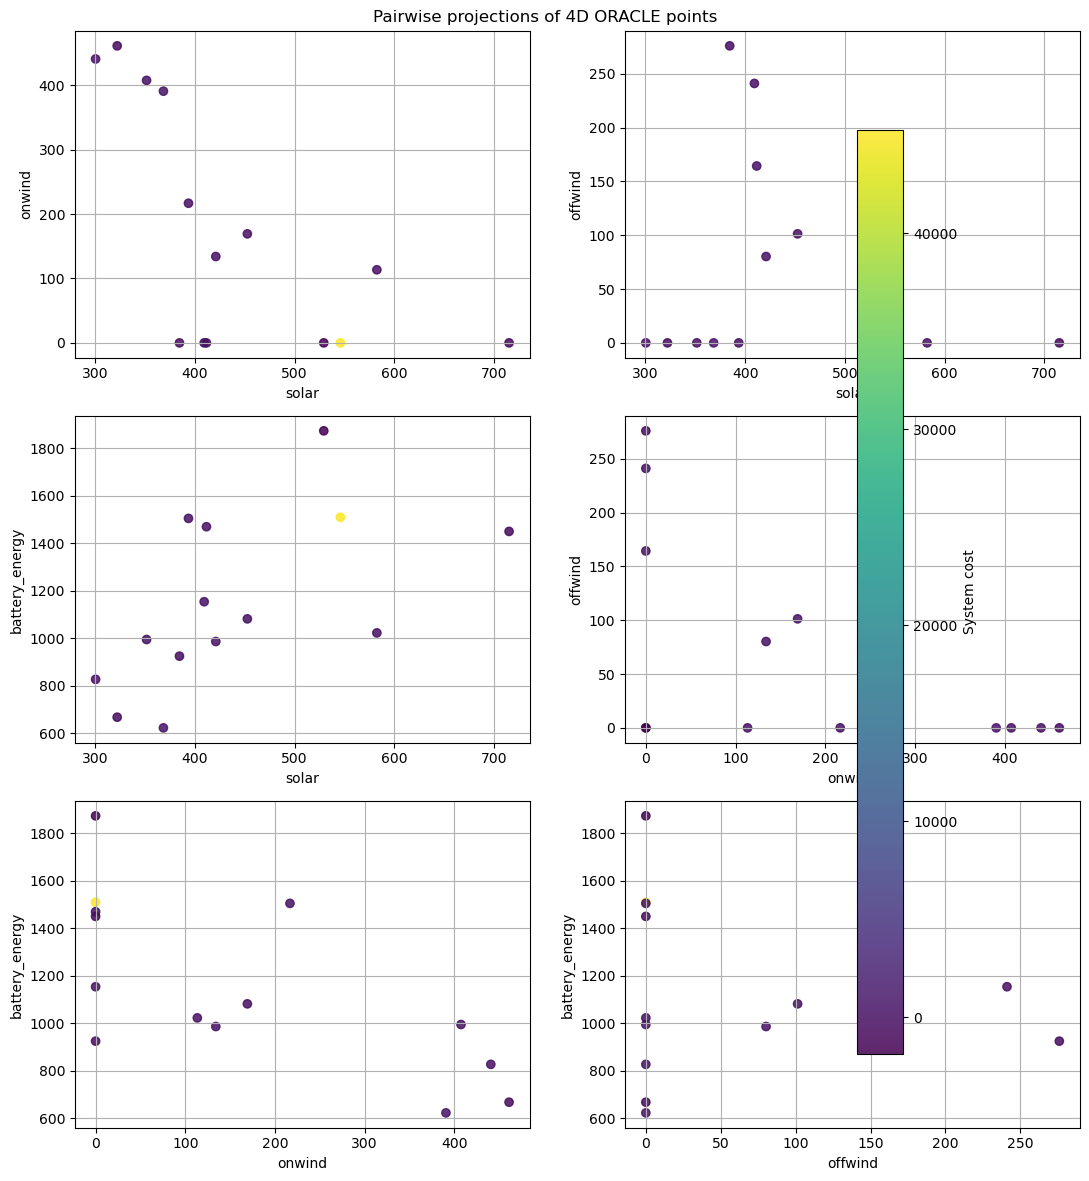

In [15]:
import itertools
import matplotlib.pyplot as plt

cols = ["solar", "onwind", "offwind", "battery_energy"]
cost_col = "objective"   # or whatever your summary column is called

fig, axes = plt.subplots(3, 2, figsize=(11, 12))
axes = axes.ravel()

for ax, (x, y) in zip(axes, itertools.combinations(cols, 2)):
    sc = ax.scatter(
        df[x],
        df[y],
        c=df[cost_col],
        alpha=0.85,
    )
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True)

fig.colorbar(sc, ax=axes, label="System cost")
fig.suptitle("Pairwise projections of 4D ORACLE points")
plt.tight_layout()
plt.show()